# Analyse des résultats du premier tour de l'élection présidentielle 2022

Ce notebook présente les étapes principales de préparation, d'analyse et de visualisation des résultats électoraux.

In [1]:
import sys
sys.path.append("../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_processing import load_data, prepare_data, get_exprimes
from analysis import (
    count_candidates,
    compute_national_scores,
    compute_department_scores,
    add_national_scores,
    add_surrepresentation
)
from visualization import plot_top_surrepresentations

## 1. Chargement des données
On charge les données brutes depuis la source publique.

In [2]:
df = load_data()
df.head()

,code_departement,libelle_departement,code_commune,libelle_commune,prenom,nom,voix
0,01,Ain,1,L'Abergement-Clémenciat,Nathalie,ARTHAUD,3
1,01,Ain,2,L'Abergement-de-Varey,Nathalie,ARTHAUD,2
2,01,Ain,4,Ambérieu-en-Bugey,Nathalie,ARTHAUD,38
3,01,Ain,5,Ambérieux-en-Dombes,Nathalie,ARTHAUD,8
4,01,Ain,6,Ambléon,Nathalie,ARTHAUD,0


## 2. Préparation des données
On reconstruit le code_commune et on crée la variable candidat.

In [3]:
df = prepare_data(df)
df[["code_departement", "code_commune", "prenom", "nom", "candidat"]].head()

,code_departement,code_commune,prenom,nom,candidat
0,01,01001,Nathalie,ARTHAUD,Nathalie ARTHAUD
1,01,01002,Nathalie,ARTHAUD,Nathalie ARTHAUD
2,01,01004,Nathalie,ARTHAUD,Nathalie ARTHAUD
3,01,01005,Nathalie,ARTHAUD,Nathalie ARTHAUD
4,01,01006,Nathalie,ARTHAUD,Nathalie ARTHAUD


## 3. Nombre de candidats
On exclut les abstentions, les votes blancs et les votes nuls pour compter les candidats.

In [4]:
df_exprimes = get_exprimes(df)
nb_candidats = count_candidates(df_exprimes)
print(f"En 2022, il y avait {nb_candidats} candidats à l'élection présidentielle.")

En 2022, il y avait 15 candidats à l'élection présidentielle.


## 4. Scores nationaux
On calcule le nombre total de voix et le pourcentage national de chaque candidat.

In [5]:
score_national = compute_national_scores(df_exprimes)
score_national

,candidat,votes_national,score_national
0,abstentions,12824169,26.307134
1,Emmanuel MACRON,9783058,20.068686
2,Marine LE PEN,8133828,16.685502
3,Jean-Luc MÉLENCHON,7712520,15.821243
4,Éric ZEMMOUR,2485226,5.098122
5,Valérie PÉCRESSE,1679001,3.444255
6,Yannick JADOT,1627853,3.339331
7,Jean LASSALLE,1101387,2.259354
8,Fabien ROUSSEL,802422,1.646066
9,Nicolas DUPONT-AIGNAN,725176,1.487605


## 5. Scores par département
On calcule les voix et les scores départementaux de chaque candidat.

In [6]:
score_departements = compute_department_scores(df_exprimes)
score_departements.head(20)

,code_departement,candidat,votes_departement,total_exprimes_departement,score_departement
0,01,Anne HIDALGO,5644,438109,1.288264
1,01,Emmanuel MACRON,92206,438109,21.046361
2,01,Fabien ROUSSEL,5938,438109,1.355370
3,01,Jean LASSALLE,10876,438109,2.482487
4,01,Jean-Luc MÉLENCHON,57832,438109,13.200368
5,01,Marine LE PEN,86755,438109,19.802150
6,01,Nathalie ARTHAUD,1658,438109,0.378445
7,01,Nicolas DUPONT-AIGNAN,8998,438109,2.053827
8,01,Philippe POUTOU,2172,438109,0.495767
9,01,Valérie PÉCRESSE,17572,438109,4.010874


## 6. Comparaison aux scores nationaux
On rattache à chaque score départemental le score national du même candidat.

In [7]:
score_departements = add_national_scores(score_departements, score_national)
score_departements.head()

,code_departement,candidat,votes_departement,total_exprimes_departement,score_departement,votes_national,score_national
0,01,Anne HIDALGO,5644,438109,1.288264,616478,1.264625
1,01,Emmanuel MACRON,92206,438109,21.046361,9783058,20.068686
2,01,Fabien ROUSSEL,5938,438109,1.355370,802422,1.646066
3,01,Jean LASSALLE,10876,438109,2.482487,1101387,2.259354
4,01,Jean-Luc MÉLENCHON,57832,438109,13.200368,7712520,15.821243


## 7. Surreprésentation
La surreprésentation mesure l'écart relatif entre le score départemental et le score national.

In [9]:
score_departements = add_surrepresentation(score_departements)
score_departements.head()

,code_departement,candidat,votes_departement,total_exprimes_departement,score_departement,votes_national,score_national,surrepresentation
0,01,Anne HIDALGO,5644,438109,1.288264,616478,1.264625,1.869212
1,01,Emmanuel MACRON,92206,438109,21.046361,9783058,20.068686,4.871644
2,01,Fabien ROUSSEL,5938,438109,1.355370,802422,1.646066,-17.659995
3,01,Jean LASSALLE,10876,438109,2.482487,1101387,2.259354,9.875984
4,01,Jean-Luc MÉLENCHON,57832,438109,13.200368,7712520,15.821243,-16.565545


## 8. Exemple sur le département 11
On affiche les résultats pour l'Aude afin de vérifier la cohérence du calcul.

In [10]:
score_departements.loc[
    score_departements["code_departement"] == "11",
    ["code_departement", "candidat", "votes_departement", "score_departement", "score_national", "surrepresentation"]
].sort_values("score_departement", ascending=False)

,code_departement,candidat,votes_departement,score_departement,score_national,surrepresentation
155,11,Marine LE PEN,64027,22.872749,16.685502,37.081572
161,11,abstentions,62972,22.495865,26.307134,-14.487587
151,11,Emmanuel MACRON,43104,15.398300,20.068686,-23.272004
154,11,Jean-Luc MÉLENCHON,42039,15.017844,15.821243,-5.077978
164,11,Éric ZEMMOUR,18434,6.585288,5.098122,29.170875
153,11,Jean LASSALLE,12382,4.423296,2.259354,95.777042
159,11,Valérie PÉCRESSE,7350,2.625685,3.444255,-23.766248
160,11,Yannick JADOT,6322,2.258446,3.339331,-32.368314
150,11,Anne HIDALGO,6166,2.202717,1.264625,74.179422
152,11,Fabien ROUSSEL,5622,2.008381,1.646066,22.010982


## 9. Visualisation
On représente les départements où un candidat est le plus surreprésenté.

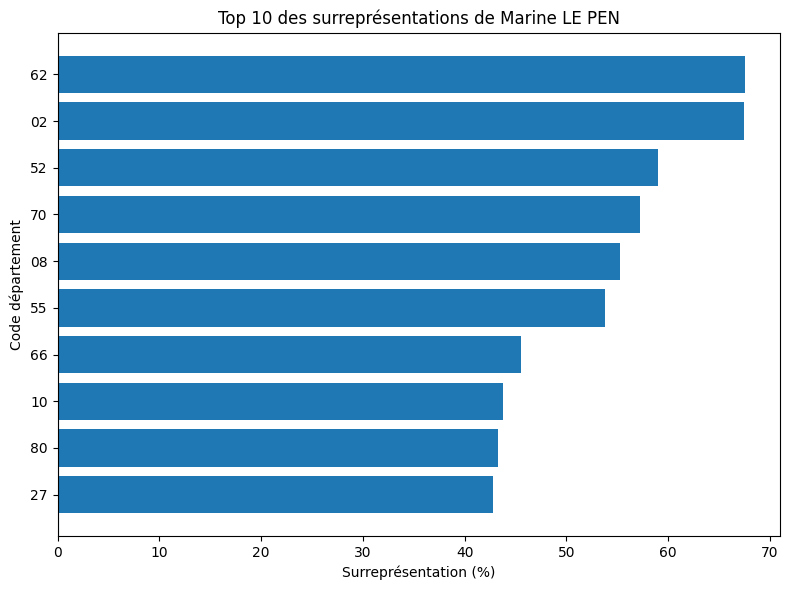

In [11]:
plot_top_surrepresentations(score_departements, "Marine LE PEN", top_n=10)

## 10. Conclusion

Cette analyse permet de passer de données électorales brutes à des indicateurs plus lisibles.  
Les scores nationaux donnent une vue d'ensemble, tandis que la surreprésentation permet d'identifier les territoires où les candidats obtiennent des résultats relativement plus élevés ou plus faibles que leur moyenne nationale.